# Monte Carlo Portfolio Simulator

This notebook downloads historical prices, estimates correlated GBM parameters, runs 100,000 Monte Carlo portfolio simulations, computes VaR and Expected Shortfall, and visualizes the results.

In [48]:
# Install packages
!pip -q install yfinance plotly

import numpy as np
import pandas as pd
import yfinance as yf
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.stats import norm


In [49]:
tickers=['AAPL','MSFT','NVDA','SPY']
weights=np.array([0.25,0.25,0.25,0.25])

prices=yf.download(tickers,start='2020-01-01',auto_adjust=True,progress=False)['Close'].dropna()
returns=np.log(prices/prices.shift(1)).dropna()

mu=returns.mean().values
cov=returns.cov().values
L=np.linalg.cholesky(cov)

days=252
paths=100000
dt=1/252

rng=np.random.default_rng(42)
Z=rng.standard_normal((days,len(tickers),paths))
corr=np.einsum('ij,tjp->tip',L,Z)

S0=prices.iloc[-1].values
asset=np.empty((days+1,len(tickers),paths))
asset[0]=S0[:,None]

drift=(mu-0.5*np.diag(cov))*dt

for t in range(1,days+1):
    asset[t]=asset[t-1]*np.exp(drift[:,None]+np.sqrt(dt)*corr[t-1])

port=(asset*weights[:,None]).sum(axis=1)
terminal=port[-1]
initial=port[0,0]
ret=(terminal-initial)/initial

var95=np.percentile(ret,5)
es95=ret[ret<=var95].mean()

print(f'VaR 95%: {var95:.2%}')
print(f'Expected Shortfall 95%: {es95:.2%}')


VaR 95%: -2.50%
Expected Shortfall 95%: -3.14%


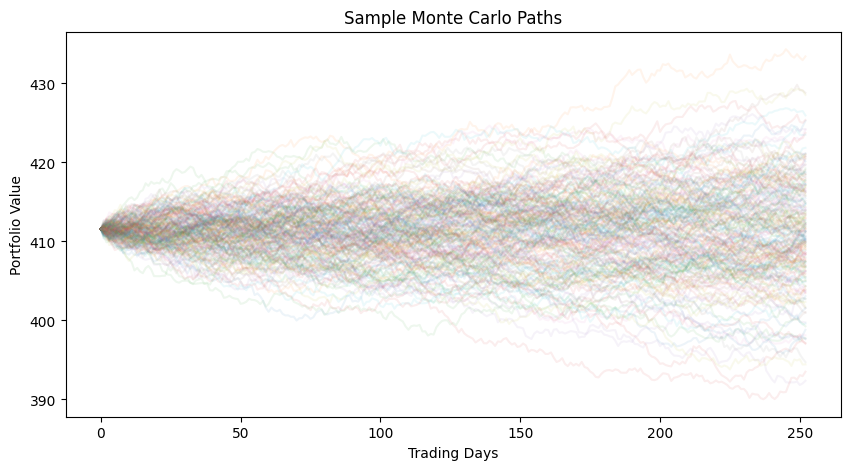

In [50]:
fig = px.histogram(
    x=ret,
    nbins=100,
    title="Terminal Portfolio Return Distribution"
)
fig.add_vline(x=var95,line_color='red',annotation_text='VaR 95%')
fig.show()

sample=np.random.choice(port.shape[1],200,replace=False)
plt.figure(figsize=(10,5))
plt.plot(port[:,sample],alpha=0.08)
plt.title('Sample Monte Carlo Paths')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value')
plt.show()

## Summary

This notebook:
- Downloads market data from Yahoo Finance.
- Estimates correlated GBM parameters.
- Simulates **100,000** future portfolio paths.
- Computes **95% VaR** and **Expected Shortfall**.
- Visualizes simulated paths and terminal return distribution.

**Resume bullet:** Built a Monte Carlo risk engine in Python using correlated geometric Brownian motion with 100,000 portfolio simulations and institutional risk metrics (VaR/CVaR) using live market data.


In [51]:
# Correlation Matrix

import plotly.express as px

corr = returns.corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlation Matrix of Portfolio Assets"
)

fig.show()

In [52]:
portfolio_returns = returns.dot(weights)

annual_return = portfolio_returns.mean() * 252
annual_vol = portfolio_returns.std() * np.sqrt(252)

sharpe = annual_return / annual_vol

cumulative = (1 + portfolio_returns).cumprod()

rolling_max = cumulative.cummax()

drawdown = cumulative / rolling_max - 1

max_drawdown = drawdown.min()

summary = pd.DataFrame({
    "Metric":[
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Value at Risk (95%)",
        "Expected Shortfall (95%)"
    ],
    "Value":[
        f"{annual_return:.2%}",
        f"{annual_vol:.2%}",
        f"{sharpe:.2f}",
        f"{max_drawdown:.2%}",
        f"{var95:.2%}",
        f"{es95:.2%}"
    ]
})

summary

,Metric,Value
0,Annual Return,26.38%
1,Annual Volatility,29.04%
2,Sharpe Ratio,0.91
3,Maximum Drawdown,-41.74%
4,Value at Risk (95%),-2.50%
5,Expected Shortfall (95%),-3.14%


In [53]:
historical = (1 + portfolio_returns).cumprod()

fig = px.line(
    historical,
    title="Historical Portfolio Growth"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Portfolio Value"
)

fig.show()

In [54]:
rolling_vol = portfolio_returns.rolling(30).std() * np.sqrt(252)

fig = px.line(
    rolling_vol,
    title="30-Day Rolling Volatility"
)

fig.update_layout(
    yaxis_title="Annualized Volatility"
)

fig.show()

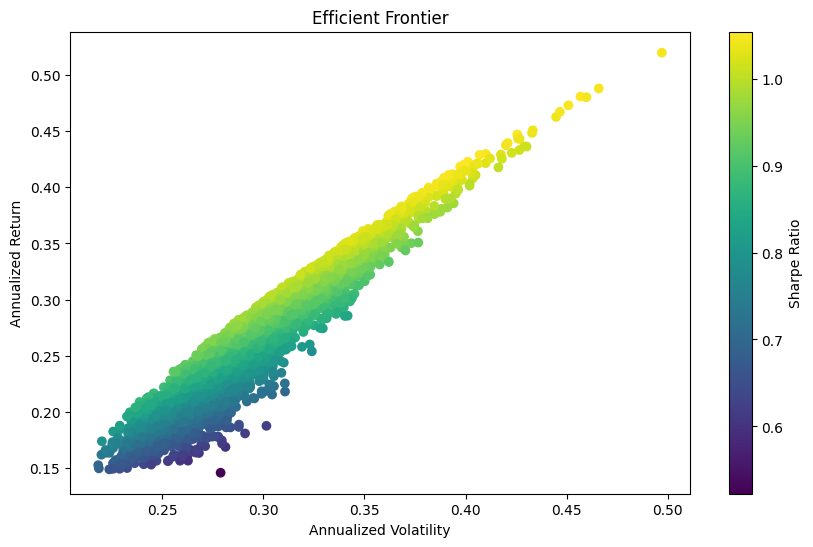

In [55]:
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

returns_mean = returns.mean() * 252
cov_matrix = returns.cov() * 252

num_portfolios = 5000

results = np.zeros((3, num_portfolios))

weights_record = []

for i in range(num_portfolios):

    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    portfolio_return = np.sum(weights * returns_mean)

    portfolio_std = np.sqrt(weights.T @ cov_matrix @ weights)

    sharpe = portfolio_return / portfolio_std

    results[0, i] = portfolio_std
    results[1, i] = portfolio_return
    results[2, i] = sharpe

plt.figure(figsize=(10,6))

plt.scatter(
    results[0],
    results[1],
    c=results[2],
    cmap='viridis'
)

plt.colorbar(label="Sharpe Ratio")

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Efficient Frontier")

plt.show()

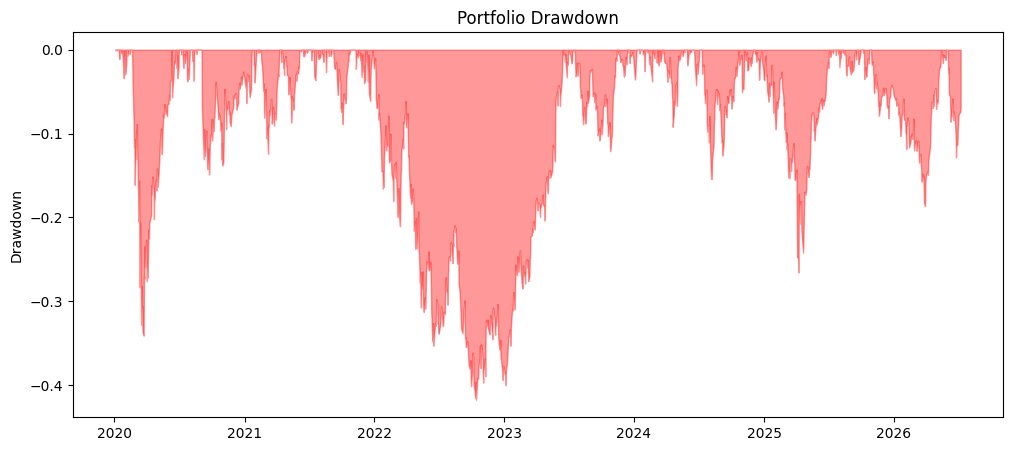

In [56]:
drawdown = cumulative / cumulative.cummax() - 1

plt.figure(figsize=(12,5))

plt.fill_between(
    drawdown.index,
    drawdown.values,
    0,
    color="red",
    alpha=0.4
)

plt.title("Portfolio Drawdown")

plt.ylabel("Drawdown")

plt.show()

In [57]:
metrics = pd.DataFrame({

"Metric":[

"Annual Return",

"Annual Volatility",

"Sharpe Ratio",

"Maximum Drawdown",

"Value at Risk",

"Expected Shortfall"

],

"Value":[

annual_return,

annual_vol,

sharpe,

max_drawdown,

var95,

es95

]

})

metrics.style.background_gradient(cmap="RdYlGn")

,Metric,Value
0,Annual Return,0.263841
1,Annual Volatility,0.290435
2,Sharpe Ratio,0.972470
3,Maximum Drawdown,-0.417378
4,Value at Risk,-0.025014
5,Expected Shortfall,-0.031396


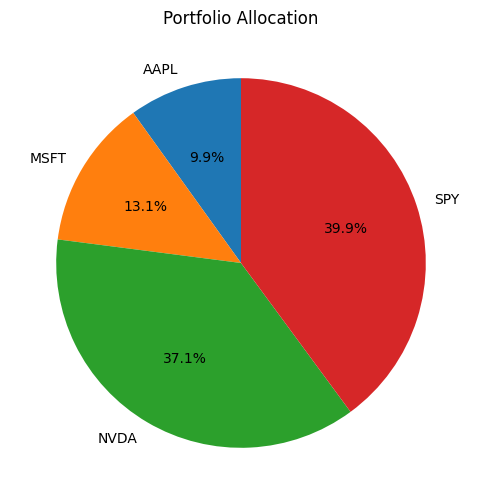

In [58]:
plt.figure(figsize=(6,6))

plt.pie(

weights,

labels=tickers,

autopct="%1.1f%%",

startangle=90

)

plt.title("Portfolio Allocation")

plt.show()

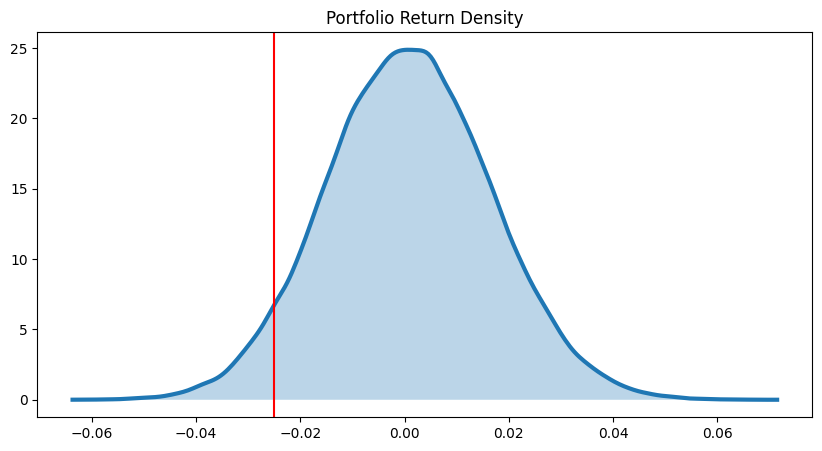

In [59]:
from scipy.stats import gaussian_kde

density = gaussian_kde(ret)

xs = np.linspace(ret.min(), ret.max(), 300)

plt.figure(figsize=(10,5))

plt.plot(xs, density(xs), linewidth=3)

plt.fill_between(xs, density(xs), alpha=0.3)

plt.axvline(var95, color='red')

plt.title("Portfolio Return Density")

plt.show()

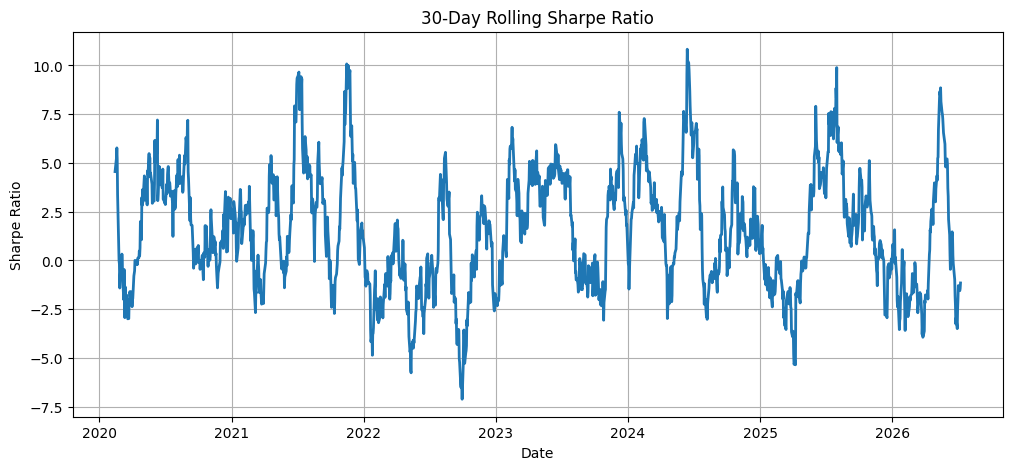

In [60]:
rolling_return = portfolio_returns.rolling(30).mean() * 252
rolling_vol = portfolio_returns.rolling(30).std() * np.sqrt(252)

rolling_sharpe = rolling_return / rolling_vol

plt.figure(figsize=(12,5))
plt.plot(rolling_sharpe, linewidth=2)
plt.title("30-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True)
plt.show()

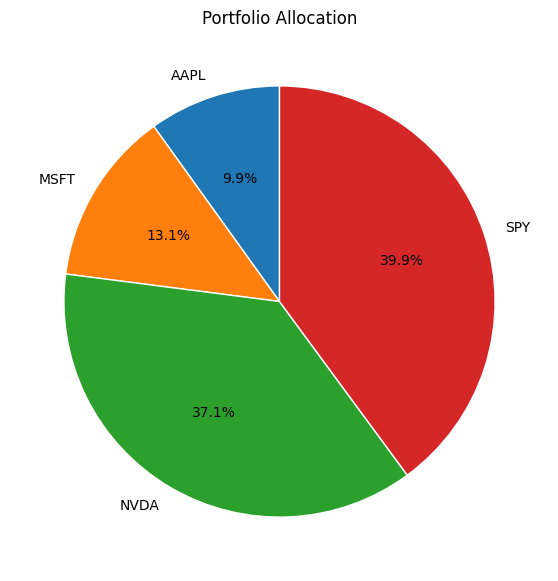

In [61]:
plt.figure(figsize=(7,7))

plt.pie(
    weights,
    labels=tickers,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white'}
)

plt.title("Portfolio Allocation")
plt.show()

,Asset,Weight,Risk Contribution
Ticker,,,
AAPL,AAPL,0.099097,0.022999
MSFT,MSFT,0.130528,0.031320
NVDA,NVDA,0.371358,0.182879
SPY,SPY,0.399017,0.071244


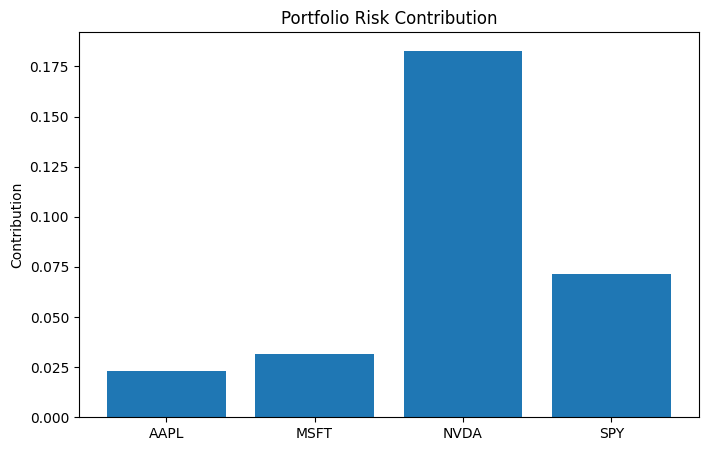

In [62]:
cov_matrix = returns.cov() * 252

portfolio_vol = np.sqrt(weights.T @ cov_matrix @ weights)

marginal_risk = cov_matrix @ weights / portfolio_vol

risk_contribution = weights * marginal_risk

risk_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": weights,
    "Risk Contribution": risk_contribution
})

display(risk_df)

plt.figure(figsize=(8,5))
plt.bar(risk_df["Asset"], risk_df["Risk Contribution"])
plt.title("Portfolio Risk Contribution")
plt.ylabel("Contribution")
plt.show()

In [63]:
prob_loss = np.mean(ret < 0)

print(f"Probability of Portfolio Loss: {prob_loss:.2%}")

Probability of Portfolio Loss: 48.08%


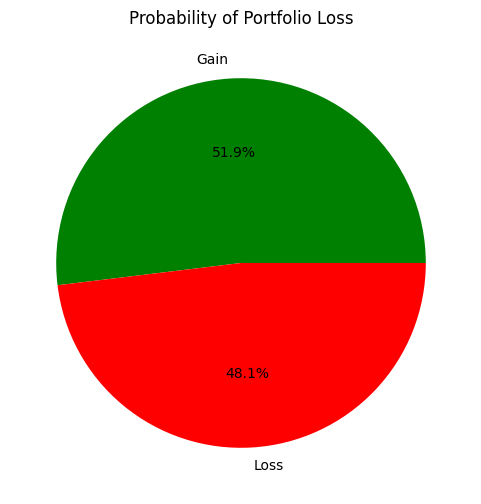

In [64]:
colors = ["green", "red"]

plt.figure(figsize=(6,6))
plt.pie(
    [1-prob_loss, prob_loss],
    labels=["Gain","Loss"],
    colors=colors,
    autopct="%1.1f%%"
)

plt.title("Probability of Portfolio Loss")
plt.show()

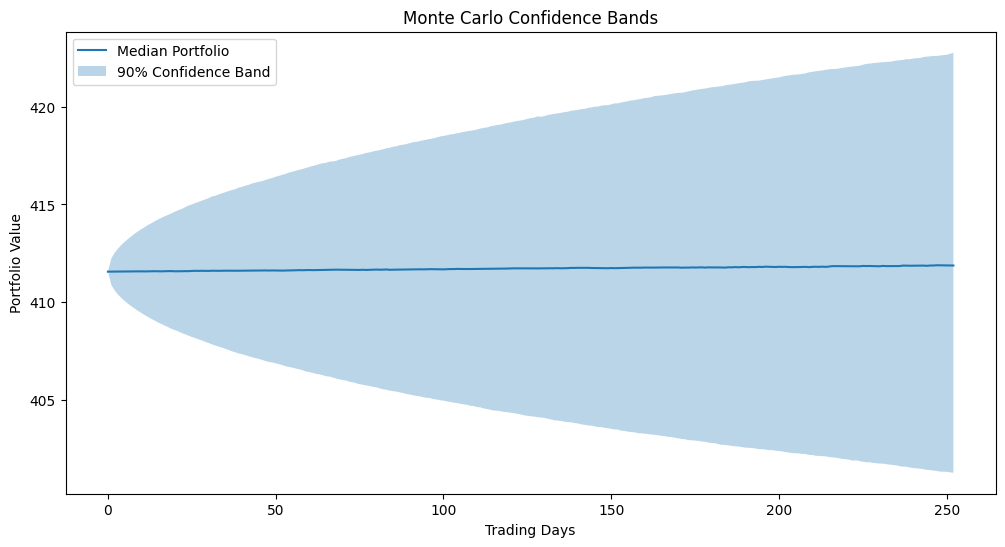

In [65]:
median = np.percentile(port, 50, axis=1)
lower = np.percentile(port, 5, axis=1)
upper = np.percentile(port, 95, axis=1)

plt.figure(figsize=(12,6))

plt.plot(median, label="Median Portfolio")

plt.fill_between(
    range(len(median)),
    lower,
    upper,
    alpha=0.3,
    label="90% Confidence Band"
)

plt.title("Monte Carlo Confidence Bands")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value")
plt.legend()
plt.show()

In [66]:
from scipy.optimize import minimize

returns_mean = returns.mean() * 252
cov_matrix = returns.cov() * 252

def neg_sharpe(weights):
    portfolio_return = np.sum(weights * returns_mean)
    portfolio_vol = np.sqrt(weights.T @ cov_matrix @ weights)
    return -(portfolio_return / portfolio_vol)

constraints = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})

bounds = tuple((0,1) for _ in tickers)

initial = np.ones(len(tickers))/len(tickers)

opt = minimize(
    neg_sharpe,
    initial,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights = opt.x

display(pd.DataFrame({
    "Asset":tickers,
    "Optimal Weight":optimal_weights
}))

,Asset,Optimal Weight
0,AAPL,2.487365e-01
1,MSFT,0.000000e+00
2,NVDA,7.512635e-01
3,SPY,3.293002e-18


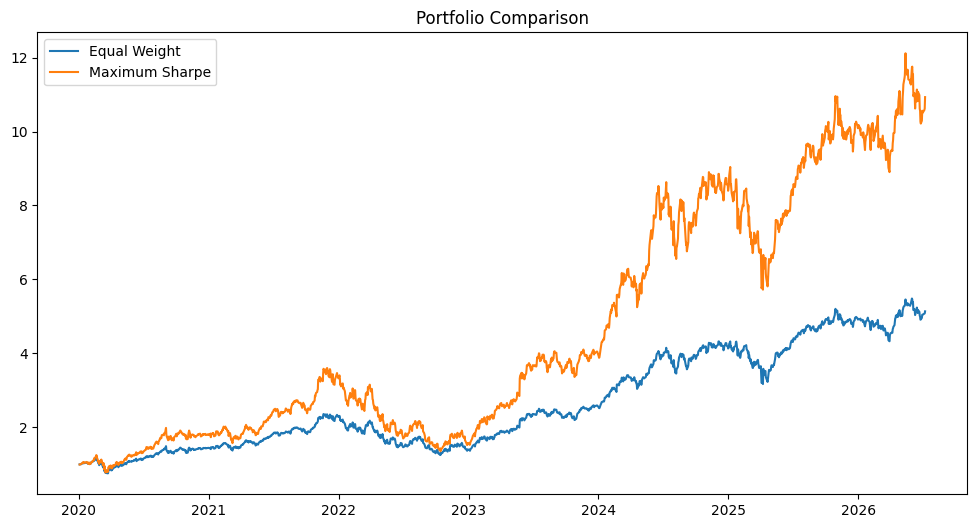

In [67]:
equal_returns = returns.dot(weights)

optimal_returns = returns.dot(optimal_weights)

cum_equal = (1+equal_returns).cumprod()

cum_opt = (1+optimal_returns).cumprod()

plt.figure(figsize=(12,6))

plt.plot(cum_equal,label="Equal Weight")

plt.plot(cum_opt,label="Maximum Sharpe")

plt.legend()

plt.title("Portfolio Comparison")

plt.show()

In [68]:
summary = pd.DataFrame({

"Metric":[

"Annual Return",

"Annual Volatility",

"Sharpe Ratio",

"VaR 95%",

"CVaR 95%",

"Probability of Loss"

],

"Value":[

f"{annual_return:.2%}",

f"{annual_vol:.2%}",

f"{sharpe:.2f}",

f"{var95:.2%}",

f"{es95:.2%}",

f"{prob_loss:.2%}"

]

})

display(summary.style.background_gradient(cmap="RdYlGn"))

,Metric,Value
0,Annual Return,26.38%
1,Annual Volatility,29.04%
2,Sharpe Ratio,0.97
3,VaR 95%,-2.50%
4,CVaR 95%,-3.14%
5,Probability of Loss,48.08%


In [69]:
stats = pd.DataFrame({

"Statistic":[

"Mean",

"Median",

"Minimum",

"Maximum",

"Std Dev"

],

"Value":[

ret.mean(),

np.median(ret),

ret.min(),

ret.max(),

ret.std()

]

})

display(stats)

,Statistic,Value
0,Mean,0.000886
1,Median,0.000761
2,Minimum,-0.063681
3,Maximum,0.071476
4,Std Dev,0.015848
